# Exploratory Data Analysis

Goal: Predict the final mAb product titer (`Y:Titer`, a single scalar per experiment) of a simulated fed-batch upstream bioprocess, from a mix of scalar process settings and daily time-series process/measurement data.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Datasets
1. *datahow_interview_train_data.csv* - training inputs (one row per Exp x day)
2. *datahow_interview_train_targets.csv* - training targets, one row per Exp
3. *datahow_interview_test_data.csv* - test inputs (same schema as train)
4. *datahow_interview_test_targets-TEMPLATE.csv* - placeholder for submission (values are dummy with 2000)

Data dictionary
- `Z:*` - process parameters, fixed per experiment (feed start/end day, feed rates, pH/temp start-end-shift, stirring, DO, experiment duration).
- `W:*` - time-varying control/input (temperature, pH, glucose/glutamine feed rate). Length matches the number of sampled days.
- `X:*` - time-varying process observations (VCD, Glc, Gln, Ammonia, Lactate, Lysed cell fraction)
- `Y:Titer` - target, measured only once at the end of the experiment.

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

DATA_DIR = "./dataset"
train_data = pd.read_csv(f"{DATA_DIR}/datahow_interview_train_data.csv")
train_targets = pd.read_csv(f"{DATA_DIR}/datahow_interview_train_targets.csv")
test_data = pd.read_csv(f"{DATA_DIR}/datahow_interview_test_data.csv")
test_targets_template = pd.read_csv(
    f"{DATA_DIR}/datahow_interview_test_targets-TEMPLATE.csv"
)

display(train_data.head())

print("train_data:", train_data.shape)
print("train_targets:", train_targets.shape)
print("test_data:", test_data.shape)
print("test_targets_template:", test_targets_template.shape)

,RowID,Exp,Time[day],Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,W:temp,W:pH,W:FeedGlc,W:FeedGln,X:VCD,X:Glc,X:Gln,X:Amm,X:Lac,X:Lysed
0,0,Exp 1,0,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,37.282828,6.808081,0.000000,0.000000,1.682644,2.853045,6.005418,0.100000,0.100000,0.000000
1,1,Exp 1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,0.000000,0.000000,3.617721,2.290199,3.598475,0.324724,1.348831,0.002831
2,2,Exp 1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,6.431879,0.752652,0.481756,0.687781,3.065268,0.000884
3,3,Exp 1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,10.279057,4.276583,2.516062,0.972871,4.196027,0.000000
4,4,Exp 1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.282828,6.808081,5.656566,6.818182,14.888965,7.350100,3.471558,1.322927,4.845310,0.000218


train_data: (990, 26)
train_targets: (100, 4)
test_data: (300, 26)
test_targets_template: (20, 4)


## 1. Data structure

Each experiment (`Exp`) is recorded as one row per day (`Time[day]`), long format:
- `Z:*` columns are only populated on day 0. These values is global constants for each experiment.
- Experiments have different durations (`Z:ExpDuration`: 7, 8, 9, 10 or 14 days), so the number of rows per experiment varies and the data is "ragged"
- The target `Y:Titer` is recorded once per experiment, at the final day (`Time[day] == Z:ExpDuration`)

In [3]:
# Now we confirm this structure

Z_COLS = [c for c in train_data.columns if c.startswith("Z:")]
W_COLS = [c for c in train_data.columns if c.startswith("W:")]
X_COLS = [c for c in train_data.columns if c.startswith("X:")]
print(f"Z (scalar) columns [{len(Z_COLS)}]:", Z_COLS)
print(f"W (control) columns [{len(W_COLS)}]:", W_COLS)
print(f"X (observed) columns [{len(X_COLS)}]:", X_COLS)

# missing-value pattern: Z only present on day 0
missing_by_day0 = (
    train_data.assign(is_day0=train_data["Time[day]"] == 0)
    .groupby("is_day0")[Z_COLS]
    .apply(lambda d: d.isna().mean())
)
print("\nFraction missing in Z columns, split by day==0 vs day>0:")
display(missing_by_day0)

n_exp_train = train_data["Exp"].nunique()
n_exp_test = test_data["Exp"].nunique()
duration_train = train_data.groupby("Exp")["Time[day]"].max()
print(f"\n# experiments -> train: {n_exp_train} & actual test: {n_exp_test}")
print("\nDistribution of experiment duration (days), train set:")
print(duration_train.value_counts().sort_index())

Z (scalar) columns [13]: ['Z:FeedStart', 'Z:FeedEnd', 'Z:FeedRateGlc', 'Z:FeedRateGln', 'Z:phStart', 'Z:phEnd', 'Z:phShift', 'Z:tempStart', 'Z:tempEnd', 'Z:tempShift', 'Z:Stir', 'Z:DO', 'Z:ExpDuration']
W (control) columns [4]: ['W:temp', 'W:pH', 'W:FeedGlc', 'W:FeedGln']
X (observed) columns [6]: ['X:VCD', 'X:Glc', 'X:Gln', 'X:Amm', 'X:Lac', 'X:Lysed']

Fraction missing in Z columns, split by day==0 vs day>0:


,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration
is_day0,,,,,,,,,,,,,
False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
True,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



# experiments -> train: 100 & actual test: 20

Distribution of experiment duration (days), train set:
Time[day]
7     30
8     20
9     20
10    20
14    10
Name: count, dtype: int64


### 1.1 Challenges of this time-series data

The characteristics of the raw data show several highlights:

1. **Ragged sequence lengths** <br>
   Bioprocesses do not have a uniform end-point. It runs vary from 7 up to 14 days. Classical ML regressors and standard sequence deep learning models expect static, uniform-length inputs, therefore we have to either transform or compress these ragged sequences.
   
2. **Scarce data** <br>
   There are only 100 training experiments. This is highly restrictive. Thus using deep learning (LSTMs, GRUs, Transformers) may overfit heavily on $N \approx 100$. This strongly motivates classical feature engineering paired with low-parameter models (non-neural-network-based model).
   
3. **Severe multicollinearity** <br>
   The features are highly collinear:
   - **Autocorrelation:** Consecutive days of process observations (e.g. VCD) are highly correlated.
   - **Cross-variable correlation:** Nutrient feed controls (`W:`) directly dictate cell growth and metabolite observation profiles (`X:`).
   - **Redundant statistics:** Summaries stats (e.g. mean, maximum, AUC, final value) of the same variable are very redundant.

4. **Inconsistency:** <br> Parameter mismtaches within the dataset. For example, in the first experiment, final Temp on day 0 (35.07070707) does not match the temperature on last day (37.28282828). In fact, they are supposed to be the same value. 


### 1.2 Cleaning & feature-engineering plan (thought experiment)

**1. Data cleaning**
1. Clip physically-impossible negative concentrations (`X:VCD`, `X:Glc`, `X:Gln`, `X:Amm`, `X:Lac`, `X:Lysed`) to 0.
2. Re-check no missing values remain in `W:*`/`X:*` after cleaning.
3. Leave `Z:*` NaNs on day > 0 as-is

**2. Feature engineering** (see implementation below)
1. Static features: all `Z:*` scalars (day-0 row).
2. Time-series summaries per `W:*`/`X:*` column: final value, max, mean, AUC (cumulative exposure/production), linear slope.
3. Domain-informed features:
   - `VCD_growth_rate`: overall specific growth rate $\ln(VCD_{final}/VCD_{initial})/\text{duration}$.
   - `VCD_time_to_peak`: day at which VCD peaks. This marks the onset of the stationary/death phase.

**3. Multicollinearity handling**

Rather than manually dropping correlated engineered features, we should rely on collinearity-robust models (e.g. PLS, regularized Ridge, tree ensembles), which are justified by correlation heatmap in the section 3.

**4. Cross-validation strategy**

K-fold splits by `n_days` (duration) as duration is the single strongest driver of titer.


In [4]:
# Validation / integrity checks
issues = []

# Confirm that Exp keys match between data and targets
train_exps, target_exps = set(train_data["Exp"]), set(train_targets["Exp"])
if train_exps != target_exps:
    issues.append(
        f"Exp mismatch between train_data and train_targets: {train_exps ^ target_exps}"
    )

# Confirm that Time[day] is a complete, gapless 0..ExpDuration index per experiment
for exp, group in train_data.groupby("Exp"):
    days = sorted(group["Time[day]"].tolist())
    expected = list(range(int(days[-1]) + 1))
    if days != expected:
        issues.append(f"{exp}: non-contiguous day index {days}")

# Confirm that Z:* populated on day 0 only, for every experiment
z_day0 = (
    train_data.loc[train_data["Time[day]"] == 0, Z_COLS].isna().any(axis=1)
)
z_other = (
    train_data.loc[train_data["Time[day]"] != 0, Z_COLS].notna().any(axis=1)
)
if z_day0.any() or z_other.any():
    issues.append("Z:* columns violate the day-0-only pattern for some rows")

# Make sure that there is no duplicate (Exp, Time[day]) rows
dup = train_data.duplicated(subset=["Exp", "Time[day]"]).sum()
if dup:
    issues.append(f"{dup} duplicate (Exp, Time[day]) rows found")

print(
    "Validation issues found:"
    if issues
    else "All validation checks passed - no issues found."
)

for issue in issues:
    print(" -", issue)

All validation checks passed - no issues found.


## 2. Data processing 

We process the data from long format (day-level) to one row per experiment because we want to turn the ragged time-series problem into a standard tabular regression problem.

We use the following featurization techniques to do so:
1. Cleaning by clipping negative concentrations to 0.
2. Taking the `Z:*` scalar parameters from the day-0 row of each experiment.
3. Summarizing each `W:*`/`X:*` time-series into informative scalar features: final value, max, mean, area-under-curve (integral over time), and linear trend (slope), plus two domain-informed features for `X:VCD` (growth rate, time to peak).


In [5]:
def clean_timeseries(df: pd.DataFrame) -> pd.DataFrame:
    """Clip physically-impossible negative concentrations/counts to 0 (plan step B)."""
    df = df.copy()
    neg_counts = (df[X_COLS] < 0).sum()
    if neg_counts.any():
        print(
            "Clipping negative values found in:",
            neg_counts[neg_counts > 0].to_dict(),
        )
    df[X_COLS] = df[X_COLS].clip(lower=0)
    return df

In [6]:
def featurize_timeseries(group: pd.DataFrame, cols: list[str]) -> dict:
    """Summarize one experiment's time-series columns into scalar features."""
    t = group["Time[day]"].to_numpy(dtype=float)
    feats = {}
    for c in cols:
        y = group[c].to_numpy(dtype=float)
        name = c.split(":", 1)[1]
        feats[f"{name}_final"] = y[-1]
        feats[f"{name}_max"] = np.nanmax(y)
        feats[f"{name}_mean"] = np.nanmean(y)
        feats[f"{name}_auc"] = np.trapezoid(y, t) if len(t) > 1 else 0.0
        slope = np.polyfit(t, y, 1)[0] if len(t) > 1 else 0.0
        feats[f"{name}_slope"] = slope

    # domain-informed features (plan step C.3), derived from VCD growth dynamics
    vcd = group["X:VCD"].to_numpy(dtype=float)
    vcd_initial = vcd[0] if vcd[0] > 0 else 1e-6
    duration = t[-1] if t[-1] > 0 else 1.0
    feats["VCD_growth_rate"] = (
        np.log(max(vcd[-1], 1e-6) / vcd_initial) / duration
    )
    feats["VCD_time_to_peak"] = t[np.argmax(vcd)]
    return feats

In [7]:
def build_experiment_table(df: pd.DataFrame) -> pd.DataFrame:
    """Collapse long (Exp, day) data into one row per experiment."""
    df = clean_timeseries(df)
    rows = []
    for exp, group in df.groupby("Exp", sort=False):
        group = group.sort_values("Time[day]")
        z_row = group.loc[group["Time[day]"] == 0, Z_COLS].iloc[0].to_dict()
        ts_feats = featurize_timeseries(group, W_COLS + X_COLS)
        rows.append(
            {
                "Exp": exp,
                "n_days": group["Time[day]"].max(),
                **z_row,
                **ts_feats,
            }
        )
    return pd.DataFrame(rows).set_index("Exp")

In [8]:
train_exp = build_experiment_table(train_data)
test_exp = build_experiment_table(test_data)

train_exp = train_exp.join(train_targets.set_index("Exp")["Y:Titer"])

print("train_exp:", train_exp.shape)
print("test_exp:", test_exp.shape)
train_exp.head()

train_exp: (100, 67)
test_exp: (20, 66)


,n_days,Z:FeedStart,Z:FeedEnd,Z:FeedRateGlc,Z:FeedRateGln,Z:phStart,Z:phEnd,Z:phShift,Z:tempStart,Z:tempEnd,Z:tempShift,Z:Stir,Z:DO,Z:ExpDuration,temp_final,temp_max,temp_mean,temp_auc,temp_slope,pH_final,pH_max,pH_mean,pH_auc,pH_slope,FeedGlc_final,...,Glc_auc,Glc_slope,Gln_final,Gln_max,Gln_mean,Gln_auc,Gln_slope,Amm_final,Amm_max,Amm_mean,Amm_auc,Amm_slope,Lac_final,Lac_max,Lac_mean,Lac_auc,Lac_slope,Lysed_final,Lysed_max,Lysed_mean,Lysed_auc,Lysed_slope,VCD_growth_rate,VCD_time_to_peak,Y:Titer
Exp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Exp 1,10,2.0,10.0,5.656566,6.818182,6.808081,6.479798,9.0,37.282828,35.070707,13.0,224.242424,43.383838,10.0,37.282828,37.282828,37.282828,372.828283,2.426695e-15,6.479798,6.808081,6.748393,67.588384,-2.685950e-02,0.000000,...,84.052505,1.501787,0.073529,6.005418,1.699388,15.653790,-0.485023,4.063493,4.063493,2.061484,20.594577,0.439514,4.828035,5.821098,3.947288,40.956149,0.387198,0.282538,0.282538,0.059261,0.510602,0.022485,0.309023,10.0,2550.097032
Exp 2,10,1.0,12.0,5.696970,6.979798,6.606061,6.207071,8.0,37.121212,35.595960,10.0,155.555556,67.121212,10.0,35.595960,37.121212,36.982553,370.449495,-6.932966e-02,6.207071,6.606061,6.497245,65.063131,-4.352617e-02,5.696970,...,217.843153,4.154249,38.988539,38.988539,19.192115,189.183768,3.566544,6.847133,6.847133,2.896085,28.383367,0.715316,7.120991,7.282656,5.085382,52.328712,0.701286,0.230921,0.230921,0.046228,0.393049,0.018635,0.062388,6.0,1278.058508
Exp 3,9,3.0,11.0,3.030303,7.242424,6.585859,6.803030,8.0,37.565657,35.818182,8.0,163.636364,64.595960,9.0,35.818182,37.565657,37.216162,335.469697,-1.694521e-01,6.803030,6.803030,6.629293,59.598485,2.105908e-02,3.030303,...,55.105478,0.606615,17.708428,17.708428,8.592562,74.765963,1.995879,4.178718,4.178718,1.507903,12.939670,0.432324,5.566270,5.730805,3.293466,30.101523,0.612346,0.039230,0.044257,0.012165,0.102039,0.003967,0.259017,9.0,1162.646534
Exp 4,9,2.0,12.0,4.484848,6.838384,6.717172,6.651515,12.0,37.787879,35.535354,12.0,194.949495,63.080808,9.0,37.787879,37.787879,37.787879,340.090909,8.606942e-16,6.717172,6.717172,6.717172,60.454545,3.265416e-16,4.484848,...,97.977054,2.478694,28.320916,28.320916,13.175479,115.392979,2.994667,4.735391,4.735391,1.884316,16.425461,0.541590,6.797757,6.797757,3.741709,33.968210,0.743174,0.089675,0.089675,0.016068,0.115842,0.006892,0.245739,8.0,1012.535606
Exp 5,8,3.0,11.0,5.090909,6.232323,7.424242,6.469697,13.0,36.979798,35.858586,8.0,222.222222,38.333333,8.0,35.858586,36.979798,36.855219,295.277778,-7.474747e-02,7.424242,7.424242,7.424242,59.393939,-4.925570e-16,5.090909,...,48.691336,1.100149,0.000000,4.775471,1.056795,7.123416,-0.395722,2.637526,2.637526,1.172803,9.186463,0.322818,5.229935,5.651819,3.641454,30.108121,0.604946,0.043197,0.043197,0.013117,0.096457,0.004464,0.334355,8.0,1132.710237


In [9]:
train_exp.to_csv(f"{DATA_DIR}/train_exp_features.csv")
print("Saved train_exp_features.csv:", train_exp.shape)
test_exp.to_csv(f"{DATA_DIR}/test_exp_features.csv")
print("Saved test_exp_features.csv:", test_exp.shape)

Saved train_exp_features.csv: (100, 67)
Saved test_exp_features.csv: (20, 66)


## 3. Visualizations

### 3.1 Target distribution


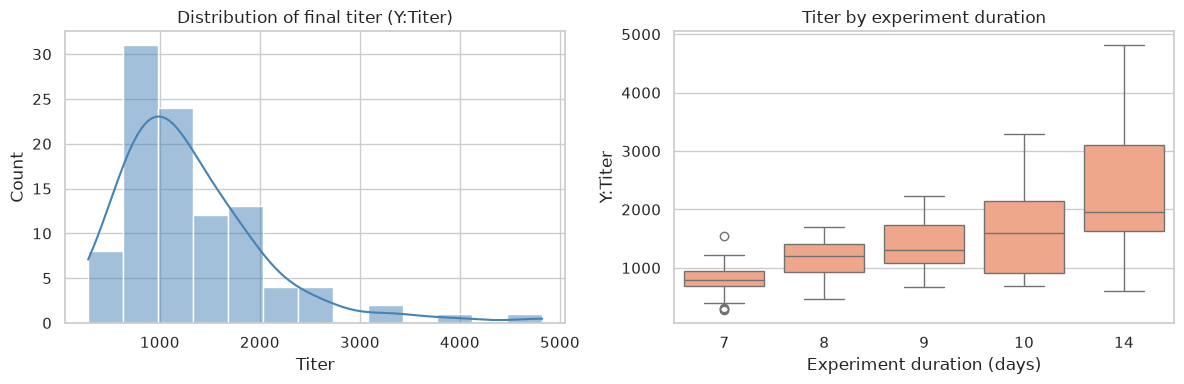

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_exp["Y:Titer"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of final titer (Y:Titer)")
axes[0].set_xlabel("Titer")

sns.boxplot(
    data=train_exp, x="n_days", y="Y:Titer", ax=axes[1], color="lightsalmon"
)
axes[1].set_title("Titer by experiment duration")
axes[1].set_xlabel("Experiment duration (days)")
plt.tight_layout()
plt.show()

In [11]:
print(train_exp["Y:Titer"].describe())
print("\nSkewness:", stats.skew(train_exp["Y:Titer"]))

count     100.000000
mean     1314.507270
std       753.087552
min       283.456126
25%       802.153610
50%      1147.678385
75%      1667.211098
max      4822.697067
Name: Y:Titer, dtype: float64

Skewness: 1.8801764674444819


Titer distribution is right-skewed (skew is around 1.9)

### 3.2 Process trajectories colored by final titer

Each line is one experiment; color encodes its final titer. This reveals which dynamic behaviors (e.g., higher/faster VCD growth, lactate accumulation) are associated with higher titer.


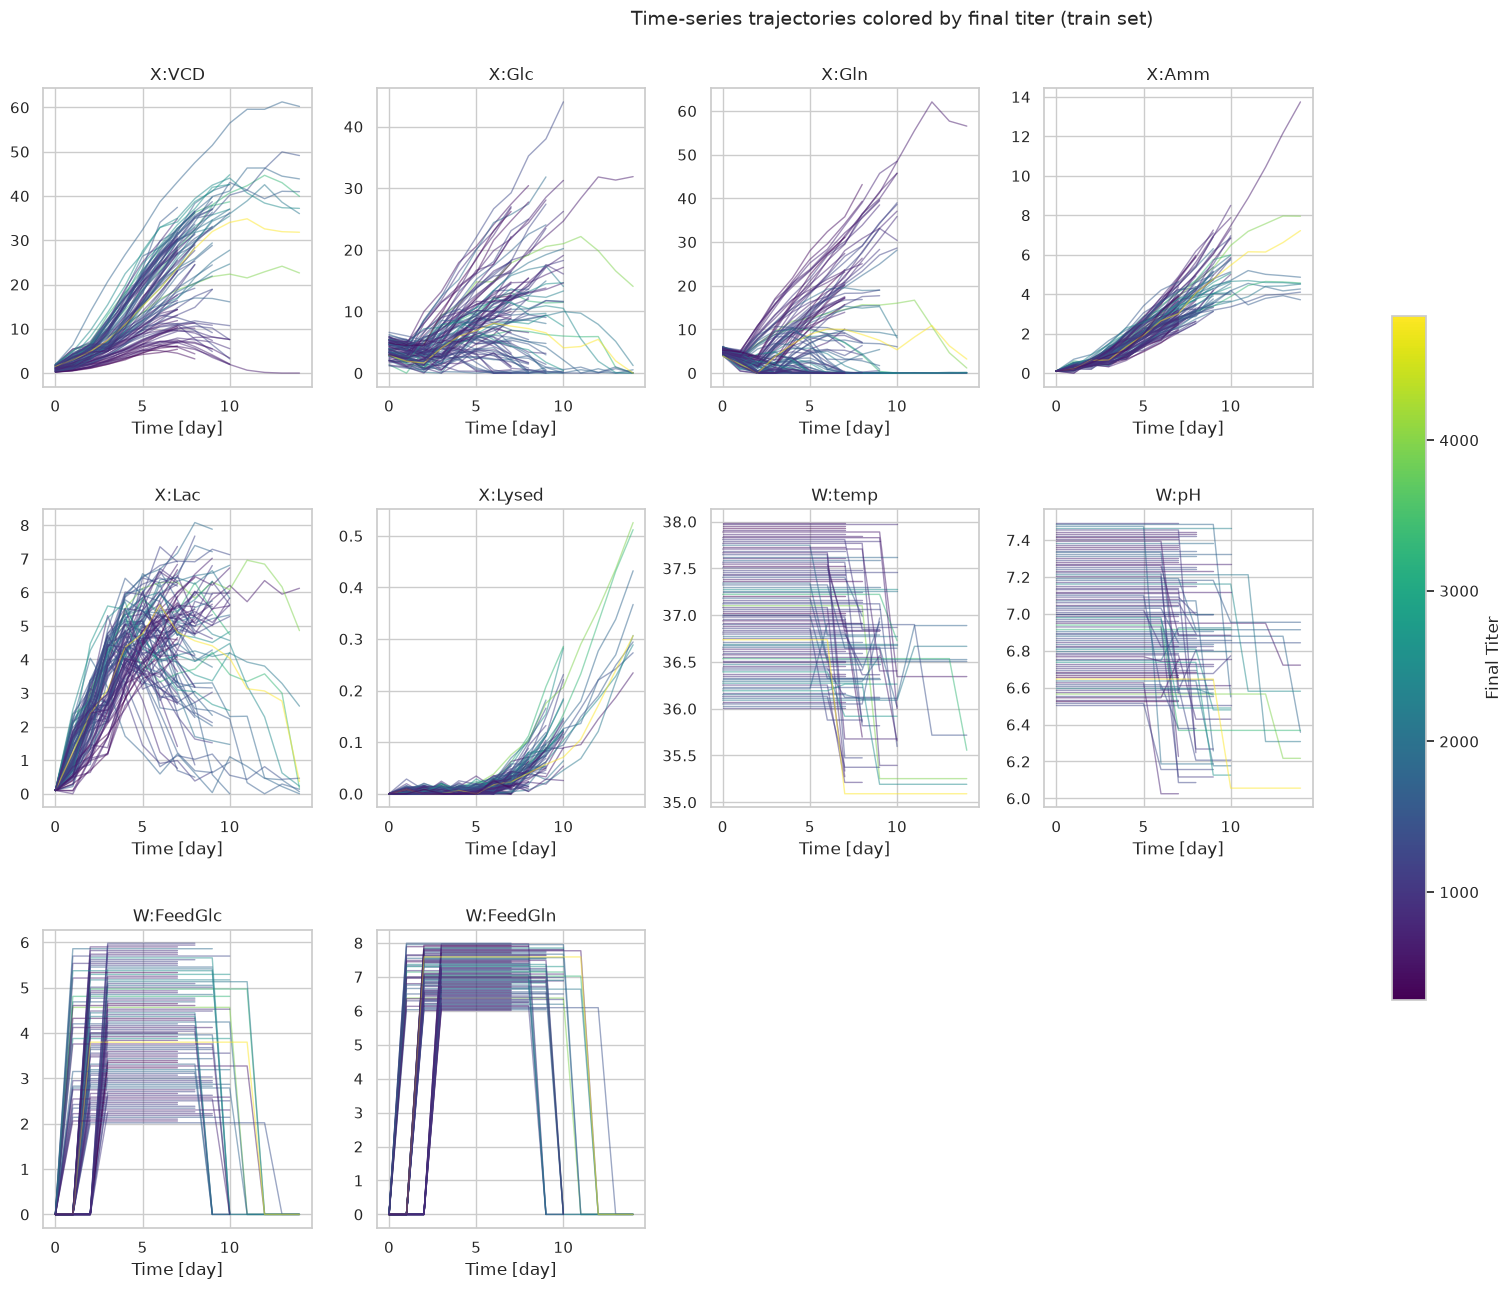

In [12]:
plot_vars = X_COLS + ["W:temp", "W:pH", "W:FeedGlc", "W:FeedGln"]
norm = plt.Normalize(train_exp["Y:Titer"].min(), train_exp["Y:Titer"].max())
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(3, 4, figsize=(18, 13), sharex=False)
axes = axes.ravel()
for ax, col in zip(axes, plot_vars):
    for exp, group in train_data.groupby("Exp", sort=False):
        group = group.sort_values("Time[day]")
        titer = train_targets.set_index("Exp").loc[exp, "Y:Titer"]
        ax.plot(
            group["Time[day]"],
            group[col],
            color=cmap(norm(titer)),
            alpha=0.5,
            linewidth=1,
        )
    ax.set_title(col)
    ax.set_xlabel("Time [day]")

for ax in axes[len(plot_vars) :]:
    ax.axis("off")

fig.tight_layout(h_pad=3.0, w_pad=2.0, rect=[0, 0, 0.92, 0.96])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes.tolist(), label="Final Titer", shrink=0.6)
fig.suptitle(
    "Time-series trajectories colored by final titer (train set)",
    y=0.99,
    fontsize=14,
)
plt.show()

### 3.3 Scalar (Z) parameter distributions and their relationship with titer


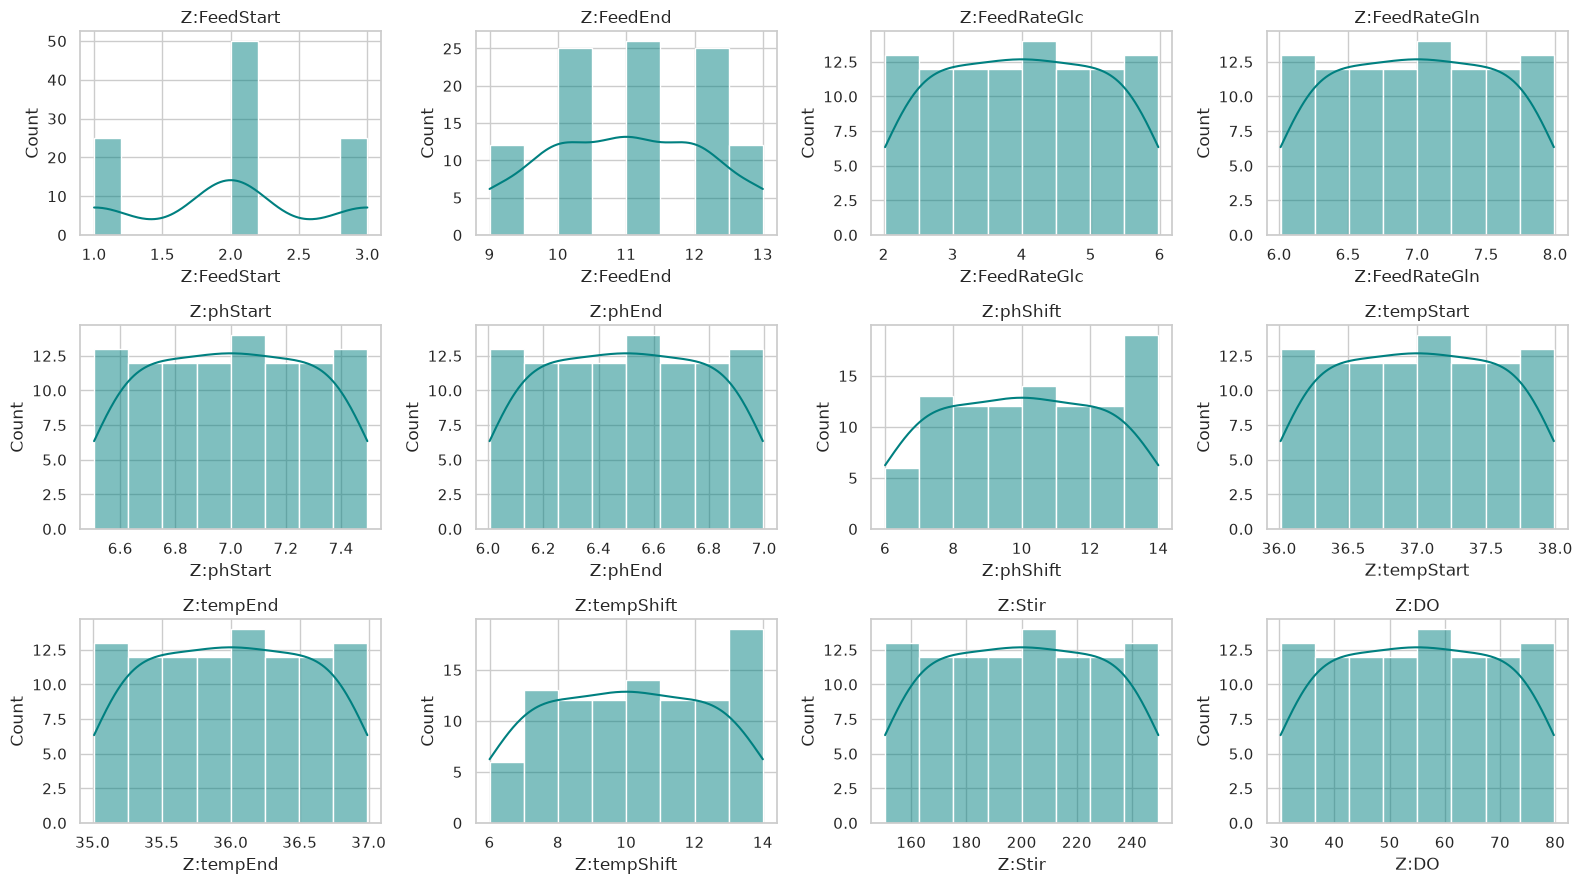

In [13]:
z_no_duration = [c for c in Z_COLS if c != "Z:ExpDuration"]
n_cols = 4
n_rows = int(np.ceil(len(z_no_duration) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.ravel()
for ax, col in zip(axes, z_no_duration):
    sns.histplot(train_exp[col], ax=ax, color="teal", kde=True)
    ax.set_title(col)
for ax in axes[len(z_no_duration) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()

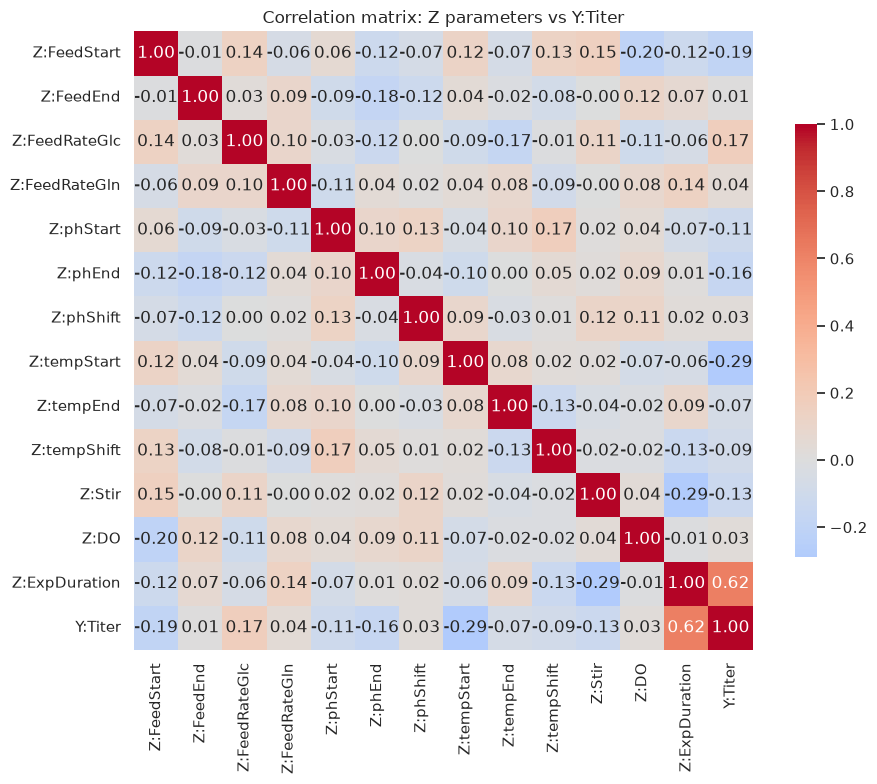

In [14]:
# Correlation heatmap: Z parameters (+ duration) vs each other and vs titer
corr_cols = Z_COLS + ["Y:Titer"]
corr = train_exp[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.7},
)
plt.title("Correlation matrix: Z parameters vs Y:Titer")
plt.tight_layout()
plt.show()

In [15]:
print("\nCorrelation of each Z parameter with Y:Titer, sorted by |r|:")
print(corr["Y:Titer"].drop("Y:Titer").sort_values(key=np.abs, ascending=False))


Correlation of each Z parameter with Y:Titer, sorted by |r|:
Z:ExpDuration    0.617820
Z:tempStart     -0.289348
Z:FeedStart     -0.185799
Z:FeedRateGlc    0.173562
Z:phEnd         -0.161592
Z:Stir          -0.132160
Z:phStart       -0.109523
Z:tempShift     -0.087102
Z:tempEnd       -0.066168
Z:FeedRateGln    0.041364
Z:phShift        0.030572
Z:DO             0.029056
Z:FeedEnd        0.006009
Name: Y:Titer, dtype: float64


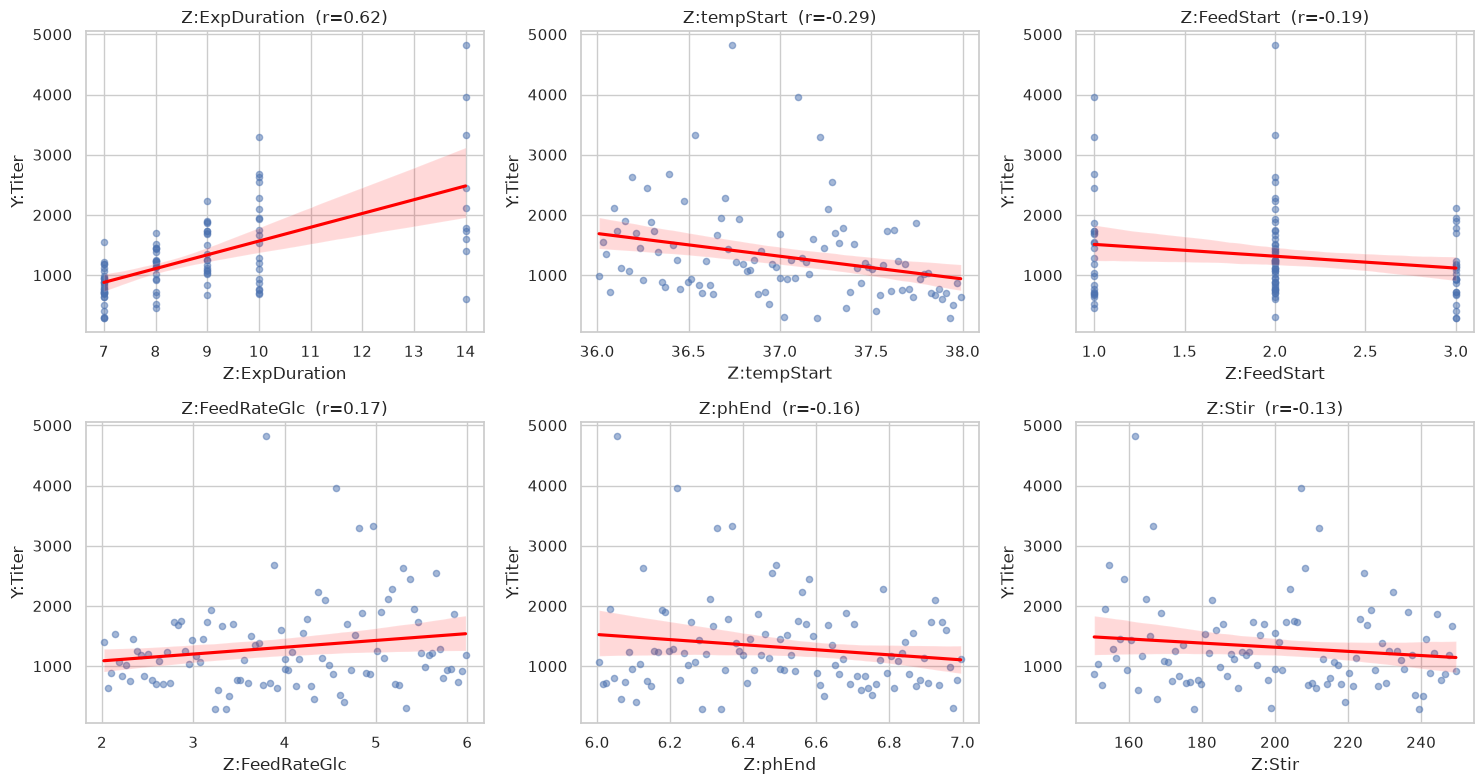

In [16]:
top_z = (
    corr["Y:Titer"]
    .drop("Y:Titer")
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), top_z):
    sns.regplot(
        data=train_exp,
        x=col,
        y="Y:Titer",
        ax=ax,
        scatter_kws={"alpha": 0.5, "s": 20},
        line_kws={"color": "red"},
    )
    r = train_exp[[col, "Y:Titer"]].corr().iloc[0, 1]
    ax.set_title(f"{col}  (r={r:.2f})")

plt.tight_layout()
plt.show()

### 3.4 Which engineered time-series features correlate most with titer?


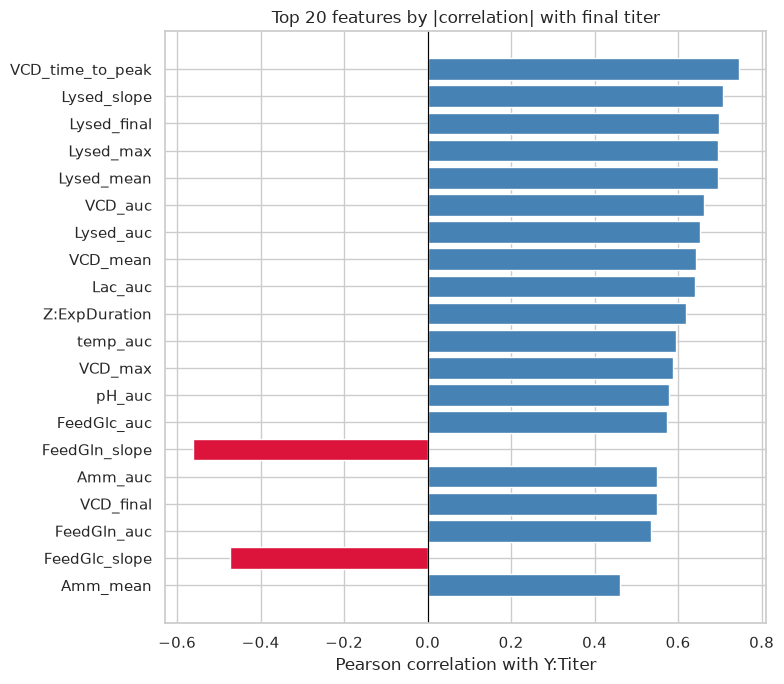

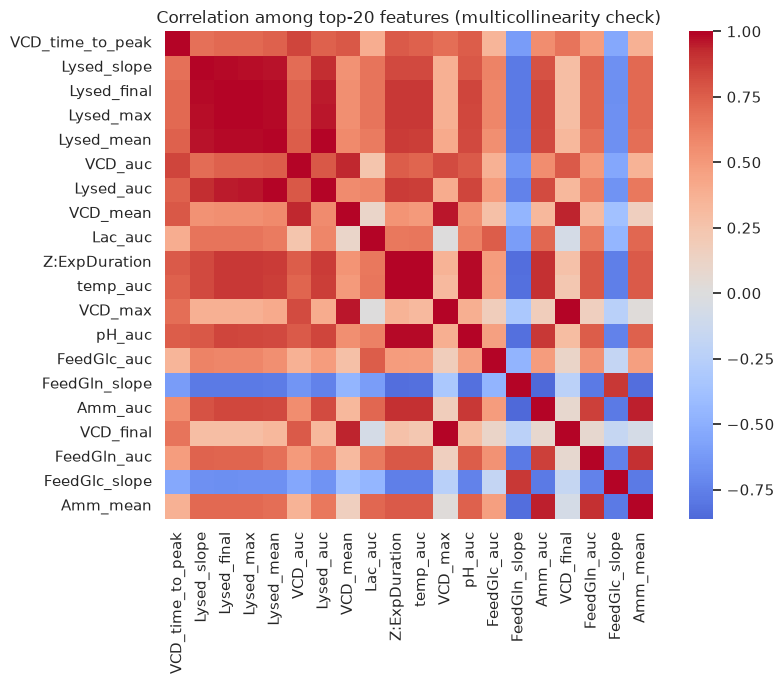

In [17]:
feature_cols = [c for c in train_exp.columns if c not in ("Y:Titer", "n_days")]
all_corr = (
    train_exp[feature_cols + ["Y:Titer"]].corr()["Y:Titer"].drop("Y:Titer")
)
top20 = all_corr.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
colors = ["crimson" if all_corr[f] < 0 else "steelblue" for f in top20.index]
plt.barh(top20.index[::-1], all_corr[top20.index][::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson correlation with Y:Titer")
plt.title("Top 20 features by |correlation| with final titer")
plt.tight_layout()
plt.show()

# multicollinearity check among top features (typical for Z process settings + derived stats)
plt.figure(figsize=(9, 7))
sns.heatmap(
    train_exp[top20.index].corr(), cmap="coolwarm", center=0, square=True
)
plt.title("Correlation among top-20 features (multicollinearity check)")
plt.tight_layout()
plt.show()

### 3.5 Per-experiment characteristics: comparing all 100 experiments

Here we look at every experiment's full characteristic to see how experiments differ from one another and how those differences map to the final titer.

In [18]:
row_indices, col_indices = np.where(train_exp < 0)
summary = pd.DataFrame(
    {
        "Row": train_exp.index[row_indices],
        "Column": train_exp.columns[col_indices],
    }
)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(summary)

print(
    f"Number of distinct columns with negative values: {summary['Column'].nunique()}"
)
print(summary["Column"].value_counts())

Number of distinct columns with negative values: 10
Column
pH_slope           83
temp_slope         77
Gln_slope          49
Glc_slope          26
FeedGlc_slope       9
Lac_slope           9
FeedGln_slope       8
Lysed_slope         3
VCD_slope           1
VCD_growth_rate     1
Name: count, dtype: int64


In [19]:
char_cols = [
    "n_days",
    "Z:FeedStart",
    "Z:FeedEnd",
    "Z:FeedRateGlc",
    "Z:FeedRateGln",
    "Z:phStart",
    "Z:phEnd",
    "Z:tempStart",
    "Z:tempEnd",
    "Z:Stir",
    "Z:DO",
    "VCD_final",
    "VCD_auc",
    "VCD_time_to_peak",
    "VCD_growth_rate",
    "FeedGlc_auc",
    "Glc_auc",
    "Lac_final",
    "Amm_final",
    "Y:Titer",
]
char_table = train_exp[char_cols].sort_values("Y:Titer", ascending=False)

# print("All 100 experiments sorted by final titer (descending):")
# with pd.option_context("display.max_rows", 100):
#     display(char_table)

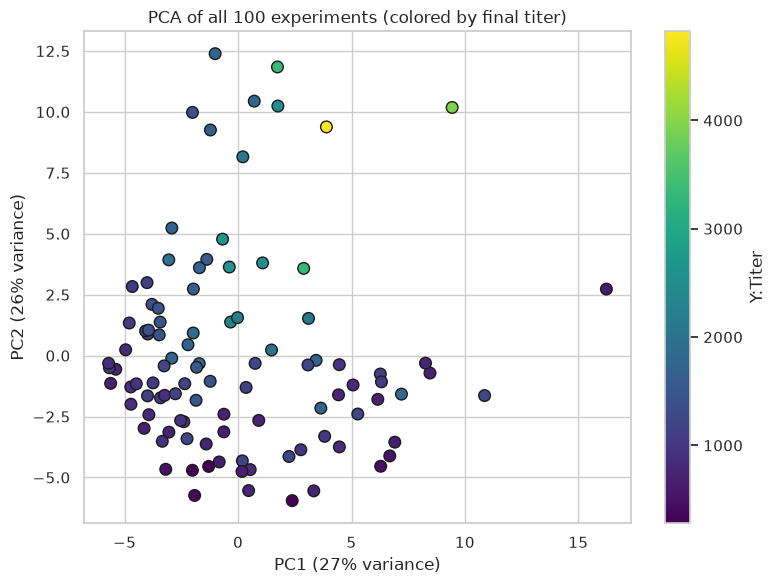

In [20]:
X_scaled = StandardScaler().fit_transform(train_exp[feature_cols])
pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    pcs[:, 0],
    pcs[:, 1],
    c=train_exp["Y:Titer"],
    cmap="viridis",
    s=70,
    edgecolor="k",
)
plt.colorbar(sc, label="Y:Titer")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)")
plt.title("PCA of all 100 experiments (colored by final titer)")
plt.tight_layout()
plt.show()

## 4. Baseline modeling & recommendation

See [baseline.ipynb](baseline.ipynb) for baseline model comparison, feature importance analysis, and the modeling recommendation.
